In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil.parser import parse

# 1. Data Preparation and Characterisation

## a) Loading, merging and saving the dataset
These two datasets are merged using `review_id`, which uniquely identifies each review in both json files. 
An inner join is used so that only reviews present in both json files are kept. The merged dataset is then saved as a CSV file so it can be reused later.

In [2]:
# Load in the data files as dataframes
scores_df = pd.read_json(r'review-scores.json')
text_df = pd.read_json(r'review-text.json')

merged_df = text_df.merge(scores_df, on='review_id', how='inner', validate='one_to_one')
merged_df.to_csv('merged_reviews.csv', index=False)

## b) Preprocessing

Some preprocessing is required to make the dataset easier to analyse. The star ratings are originally stored as strings of asterisks, so they are converted into numeric values from 1 to 5. Null review titles or review bodies are replaced with empty strings so that the text fields can be safely combined.

The title and body are then merged into one text field called `full_text`. This gives each review a single review text that can be used for text classification.

Two simple descriptive text features are created: the number of words and the number of characters in each review. These will be useful for characterising the dataset. Finally, the review date values are parsed into a consistent format.


In [3]:
# Convert stars to numeric values
rating_map = {'*': 1, '**': 2, '***': 3, '****': 4, '*****': 5}

merged_df['rating_num'] = merged_df['rating'].map(rating_map)

# Fill any null text entries
merged_df['review_title'] = merged_df['review_title'].fillna('')
merged_df['review_body'] = merged_df['review_body'].fillna('')

# Merge review text
merged_df['full_text'] = (merged_df['review_title'] + " " + merged_df['review_body']).str.strip().str.lower()

# Create text statistics 
merged_df['num_words'] = merged_df['full_text'].str.split().str.len()
merged_df['num_chars'] = merged_df['full_text'].str.len()

# Clean date entries
merged_df['review_date'] = merged_df['review_date'].apply(parse)

# Save the modifications to the csv
merged_df.to_csv('merged_reviews.csv', index=False)

## c) Characterisation of the Dataset

### Summary Statistics

In [4]:
print("Number of reviews:", len(merged_df))
print("Number of columns:", merged_df.shape[1])
print("Number of unique products:", merged_df['product_id'].nunique())
print("Number of unique users:", merged_df['user_id'].nunique())

print("\nDate range:")
print(merged_df['review_date'].min(), "to", merged_df['review_date'].max())

Number of reviews: 15375
Number of columns: 13
Number of unique products: 6331
Number of unique users: 9786

Date range:
2021-01-01 00:00:00 to 2025-12-30 00:00:00


In [5]:
# Summary statistics for numeric columns
merged_df[[
    'rating_num',
    'helpful_votes',
    'total_votes',
    'num_words',
    'num_chars'
]].describe()

,rating_num,helpful_votes,total_votes,num_words,num_chars
count,15375.000000,15375.000000,15375.000000,15375.000000,15375.000000
mean,3.414504,21.933268,27.129041,153.537106,857.228813
std,1.746735,36.306475,37.193280,161.384585,916.136991
min,1.000000,0.000000,12.000000,0.000000,0.000000
25%,1.000000,10.000000,14.000000,59.000000,324.000000
50%,4.000000,14.000000,18.000000,106.000000,580.000000
75%,5.000000,22.000000,26.000000,187.000000,1038.000000
max,5.000000,866.000000,923.000000,2157.000000,12563.000000


The above summary statistics show that the average star rating is around 3.41, and the median rating is 4. This might mean that the ratings are very polarised between high and low ratings.

The average review length is about 153 words, but the standard deviation is very large. This means that review length varies a lot. Helpful votes also vary strongly.

### Distributions
The following plots show the distributions of some key features in the dataset.

rating_num
1    4324
2    1153
3    1187
4    1248
5    7463
Name: count, dtype: int64


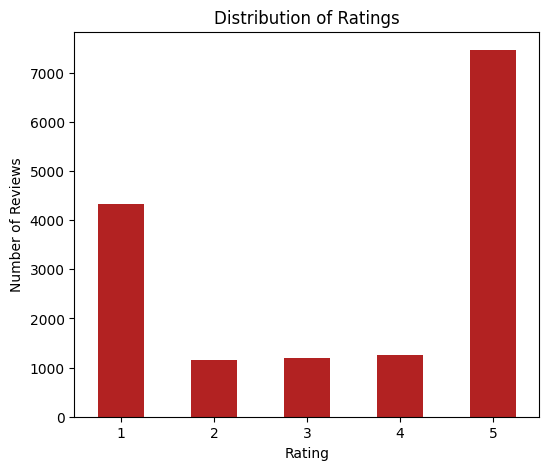

In [6]:
# Percentage of reviews at each score
rating_counts = merged_df['rating_num'].value_counts().sort_index()
print(rating_counts)

plt.figure(figsize=(6,5))
rating_counts.plot(kind='bar', color='firebrick')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

From the above plot we can see that the rating distribution is not balanced. Five-star reviews are the most common, followed by one-star reviews. Ratings of 2, 3 and 4 stars appear much less often. This will be important for classification as uneven distributions can affect the model's performance.

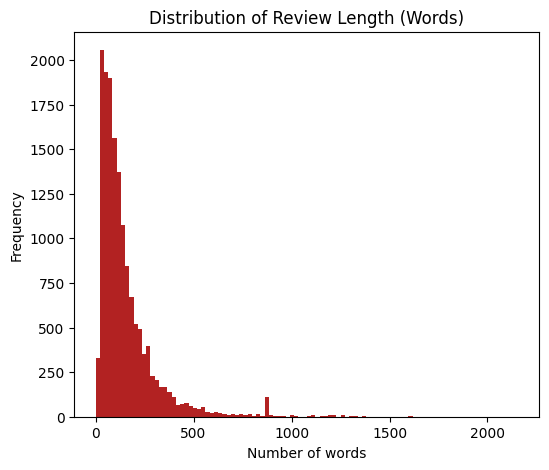

In [7]:
# Distribution of review length
plt.figure(figsize=(6,5))
merged_df['num_words'].plot(kind='hist', bins=100, color='firebrick')
plt.title('Distribution of Review Length (Words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.show()

Most reviews are relatively short <100 words, while a small number of reviews are much longer.

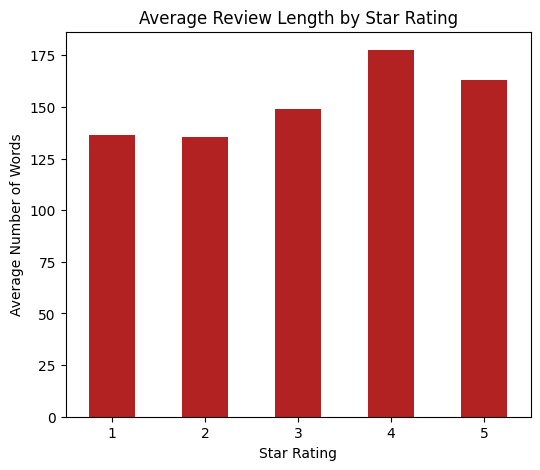

In [8]:
# Average review length by rating
avg_words = merged_df.groupby('rating_num')['num_words'].mean()

plt.figure(figsize=(6,5))
avg_words.plot(kind="bar", color='firebrick')
plt.title("Average Review Length by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

This plot shows that review length varies by rating. Four and five-star reviews are longer on average than the lowest rated reviews, although the relationship is not perfectly increasing.

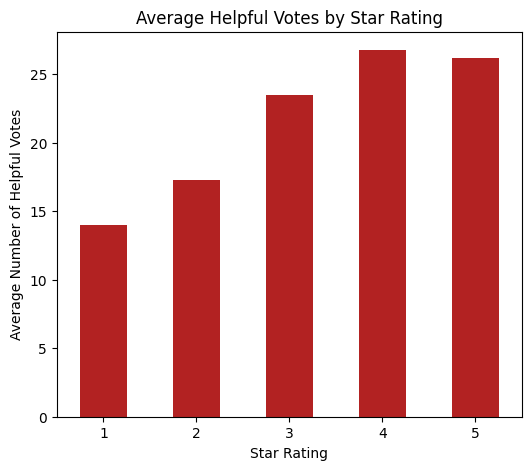

In [9]:
# Average review length by rating
avg_words = merged_df.groupby('rating_num')['helpful_votes'].mean()

plt.figure(figsize=(6,5))
avg_words.plot(kind="bar", color='firebrick')
plt.title("Average Helpful Votes by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Average Number of Helpful Votes")
plt.xticks(rotation=0)
plt.show()

This plot shows that generally reviews with more helpful votes tend to be more positive and give higher ratings.

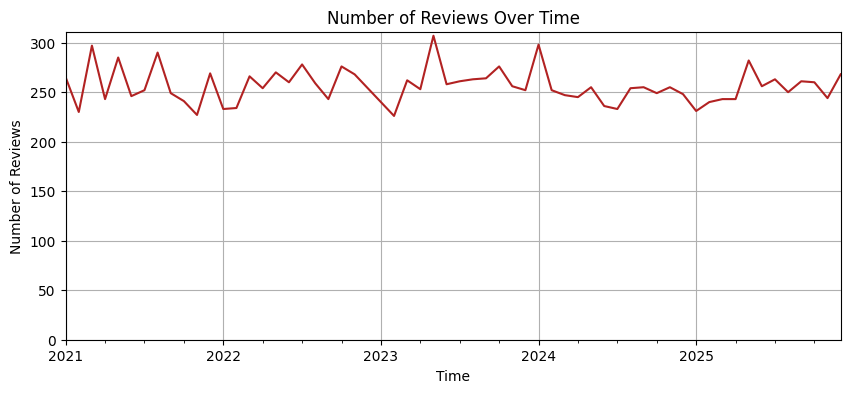

In [10]:
# Reviews over the time range 2021 - 2026
reviews_per_month = merged_df.set_index('review_date').resample("ME").size()

plt.figure(figsize=(10,4))
reviews_per_month.plot(color='firebrick')
plt.title("Number of Reviews Over Time")
plt.xlabel("Time")
plt.grid(True)
plt.ylim(bottom=0)
plt.ylabel("Number of Reviews")
plt.show()

The time-series plot shows that the reviews are spread relatively evenly across the years staying within the 250-300 reviews range consistently.

# 2. Review Sentiment Classification

## a) Sentiment Label

To perform sentiment classification, the original star ratings must be converted into sentiment categories. Rather than predicting the exact star score, this task groups ratings into broader sentiment classes.

A three-class sentiment label was chosen:

- **1–2 stars** is negative  
- **3 stars** is neutral  
- **4–5 stars** is positive  

This keeps the neutral middle rating separate, while grouping clearly positive and clearly negative reviews together. 

In [11]:
# Assign sentiment labels based on star rating
sentiment_map = {1: 'negative', 2: 'negative', 3: 'neutral', 4: 'positive', 5: 'positive'}

merged_df['sentiment_label'] = merged_df['rating_num'].map(sentiment_map)

# Save the modifications to the csv
merged_df.to_csv('merged_reviews.csv', index=False)

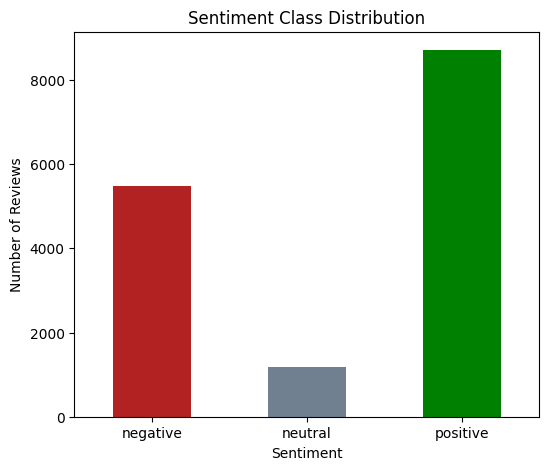

In [12]:
# Sentiment class distribution
plt.figure(figsize=(6,5))

merged_df['sentiment_label'].value_counts().sort_index().plot(
    kind="bar",
    color=["firebrick", "slategrey", "green"]
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

The class distribution plot shows that the sentiment classes are not evenly balanced.

Positive reviews are the largest class, while neutral reviews are much less common than the other two categories. This imbalance is important because classifiers may find it easier to predict the larger classes and may perform worse on the smaller neutral class.

## b) Building Sentiment Classification Models

In addition to the `full_text`, a small set of numeric features is included:

- `num_words`
- `num_chars`
- `helpful_votes`

`rating_num` cannot be used as it was used to derive the sentiment labels

These features may improve classification because positive reviews are often longer and have more positive votes, as seen in section 1c.

In [13]:
# Features for sentiment classification
X_sentiment = merged_df[
    ['full_text', 'num_words', 'num_chars', 'helpful_votes']
]

# Target label
y_sentiment = merged_df['sentiment_label']

In [14]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data, train_target, test_target = train_test_split(
    X_sentiment,
    y_sentiment,
    test_size=0.2,
    random_state=37,
    stratify=y_sentiment
)

The two different classifiers used are K-Nearest Neighbours and a Decision Tree.

KNN classifies a review based on the classes of nearby reviews in the feature space. A Decision Tree learns a set of rules based on the feature values. These two models are useful to compare because they work in different ways.

Before training the KNN model, the numeric features are scaled using Min-Max normalisation.

This rescales each feature so that all values lie between 0 and 1. Scaling is important for KNN because the model uses distances between data points. Without scaling, features with much larger ranges could dominate the distance calculations.

The Decision Tree model does not require scaling, so it will still use the original feature values.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Preprocessing for mixed text + numeric features
preprocessor_sentiment = ColumnTransformer(
    transformers=[
        # Text feature
        ('text', Pipeline([
            ('vec', CountVectorizer(stop_words='english', min_df=5)),
            ('tfidf', TfidfTransformer())
        ]), 'full_text'),

        # Numeric features
        ('num', MinMaxScaler(),
         ['num_words', 'num_chars', 'helpful_votes'])
    ]
)

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# KNN classifier
knn_pipeline = Pipeline([
    ('prep', preprocessor_sentiment),
    ('clf', KNeighborsClassifier(n_neighbors=9))
])

knn_pipeline.fit(train_data, train_target)

knn_pred = knn_pipeline.predict(test_data)

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree classifier
tree_pipeline = Pipeline([
    ('prep', preprocessor_sentiment),
    ('clf', DecisionTreeClassifier(random_state=37))
])

tree_pipeline.fit(train_data, train_target)

tree_pred = tree_pipeline.predict(test_data)

The predictions from both models are stored so that their performance can be evaluated and compared

## c) Evaluation and Comparison of the Models

The two sentiment classification models are evaluated using the test set that was held back during the train-test split.

Accuracy is used as an initial measure of performance, but it is not enough on its own because the classes are imbalanced. For this reason, precision, recall and F1-score are also reported for each class.

A confusion matrix is also used to show where each model is making correct and incorrect predictions.

In [18]:
from sklearn.metrics import accuracy_score

# Calculate and print overall accuracy for both sentiment models
print("KNN Sentiment Accuracy:", round(accuracy_score(test_target, knn_pred), 5))
print("Tree Sentiment Accuracy:", round(accuracy_score(test_target, tree_pred), 5))

KNN Sentiment Accuracy: 0.70959
Tree Sentiment Accuracy: 0.79252


The KNN sentiment model achieved an accuracy of 0.71, while the Decision Tree achieved a higher accuracy of 0.79. The Decision Tree performed better on the test set.

In [19]:
from sklearn.metrics import classification_report

# Print precision, recall and F1-score for each sentiment class
print("KNN Sentiment Classification Report")
print(classification_report(test_target, knn_pred))

print("Decision Tree Sentiment Classification Report")
print(classification_report(test_target, tree_pred))

KNN Sentiment Classification Report
              precision    recall  f1-score   support

    negative       0.74      0.50      0.60      1095
     neutral       0.96      0.11      0.19       238
    positive       0.70      0.92      0.79      1742

    accuracy                           0.71      3075
   macro avg       0.80      0.51      0.53      3075
weighted avg       0.73      0.71      0.68      3075

Decision Tree Sentiment Classification Report
              precision    recall  f1-score   support

    negative       0.76      0.78      0.77      1095
     neutral       0.47      0.40      0.43       238
    positive       0.85      0.85      0.85      1742

    accuracy                           0.79      3075
   macro avg       0.70      0.68      0.69      3075
weighted avg       0.79      0.79      0.79      3075



The classification reports give more detail than accuracy alone. For KNN, the positive class has the strongest F1-score at 0.79, while the neutral class has a very low F1-score of 0.19. This shows that KNN rarely predicts the neutral class correctly, even though its precision for neutral is high.

The Decision Tree gives better balanced results. It achieves an F1-score of 0.77 for negative reviews, 0.43 for neutral reviews, and 0.85 for positive reviews. Although neutral is still the weakest class, the Decision Tree performs much better on it than KNN.

The weighted average F1-score also improves from 0.68 for KNN to 0.79 for the Decision Tree, confirming that the Decision Tree is the stronger overall sentiment classifier.

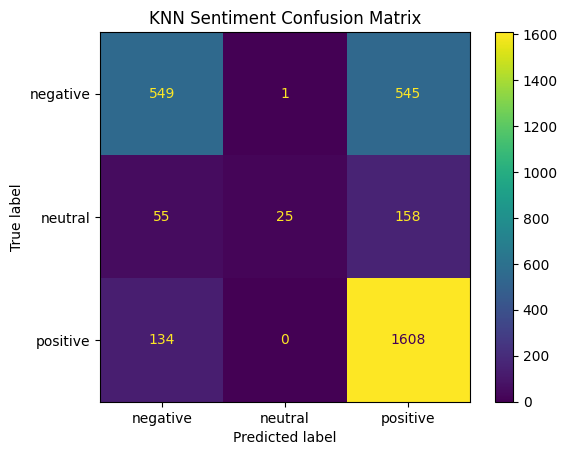

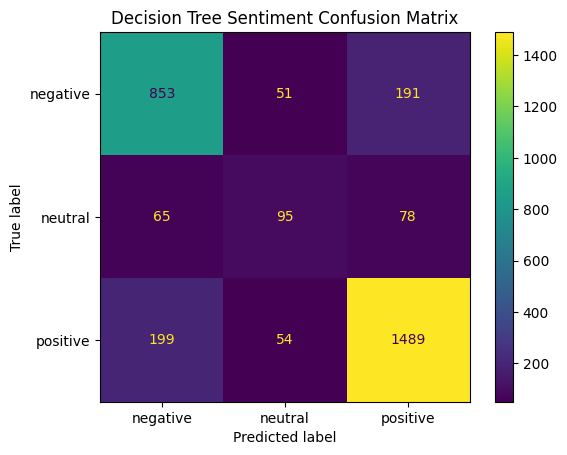

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot confusion matrix for both models
ConfusionMatrixDisplay.from_predictions(test_target, knn_pred, labels=['negative', 'neutral', 'positive'])
plt.title("KNN Sentiment Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(test_target, tree_pred, labels=['negative', 'neutral', 'positive'])
plt.title("Decision Tree Sentiment Confusion Matrix")
plt.show()

The confusion matrices show that both models predict positive reviews most successfully. This is expected because positive reviews are the largest class in the dataset.

KNN performs poorly on the neutral class, correctly predicting only 25 neutral reviews. The Decision Tree performs better on this class, correctly predicting 95 neutral reviews, although neutral reviews are still the hardest class to classify.

In [21]:
from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation for the KNN pipeline
knn_scores = cross_val_score(
    knn_pipeline,
    X_sentiment,
    y_sentiment,
    cv=10,
    scoring="accuracy"
)

# Print fold scores and average score
print("KNN Sentiment cross-validation scores:")
print(knn_scores)
print("Mean KNN Sentiment CV accuracy:", round(knn_scores.mean(), 5))

KNN Sentiment cross-validation scores:
[0.76592978 0.69635891 0.7106632  0.73016905 0.72171651 0.74625895
 0.75666884 0.75471698 0.7085231  0.73649967]
Mean KNN Sentiment CV accuracy: 0.73275


In [22]:
# Perform 10-fold cross-validation for the Decision Tree pipeline
tree_scores = cross_val_score(
    tree_pipeline,
    X_sentiment,
    y_sentiment,
    cv=10,
    scoring="accuracy"
)

# Print fold scores and average score
print("Decision Tree Sentiment cross-validation scores:")
print(tree_scores)
print("Mean Decision Tree Sentiment CV accuracy:", round(tree_scores.mean(), 5))

Decision Tree Sentiment cross-validation scores:
[0.79063719 0.78478544 0.79713914 0.81664499 0.81989597 0.80091087
 0.81132075 0.78985036 0.78529603 0.80026025]
Mean Decision Tree Sentiment CV accuracy: 0.79967



Overall, the Decision Tree was the stronger model for sentiment classification. It achieved higher test accuracy, better cross-validation accuracy, and made fewer classification errors than KNN.

Both models found the neutral class difficult to predict, likely because it contains fewer reviews than the positive and negative classes. However, the Decision Tree handled this class better than KNN.

In summary, the Decision Tree is the preferred model for this sentiment classification task.

# 3. Review Helpfulness Classification

## a) Helpfulness Label

The helpfulness score is created using the ratio:

helpful_ratio = helpful_votes / total_votes

This gives the proportion of voters who found the review helpful.

To create a binary target label:

- reviews with a helpfulness ratio above 0.7  are labelled **helpful**
- reviews less than 0.70 are labelled **unhelpful**

A threshold of 0.70 was chosen to represent strong agreement that a review was useful.

In [23]:
# Create helpfulness ratio
merged_df['helpful_ratio'] = (merged_df['helpful_votes'] / merged_df['total_votes'])

In [24]:
# Create binary helpfulness labels, 1 = helpful, 0 = unhelpful
merged_df['helpful_label'] = np.where(merged_df['helpful_ratio'] >= 0.7, 1, 0)

# Save updated dataset
merged_df.to_csv('merged_reviews.csv', index=False)

helpful_label
0     4205
1    11170
Name: count, dtype: int64


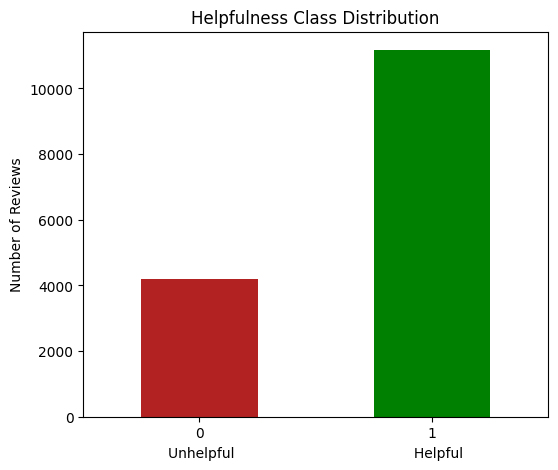

In [25]:
# Plot helpfulness class distribution
helpful_counts = merged_df['helpful_label'].value_counts().sort_index()
print(helpful_counts)

plt.figure(figsize=(6,5))

helpful_counts.plot(
    kind='bar',
    color=['firebrick', 'green']
)

plt.title("Helpfulness Class Distribution")
plt.xlabel("Unhelpful                                         Helpful")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

The class distribution plot shows that the dataset is imbalanced. There are around 4,000 unhelpful reviews and 11,000 helpful reviews.

Helpful reviews are more common in the dataset. Because of this imbalance, accuracy alone may not be enough to evaluate the helpfulness classifiers, so precision, recall and F1-score should also be considered.

## b) Building Helpfulness Classification Models

In addition to the `full_text`, a small set of numeric features is included:

- `num_words`
- `num_chars`
- `rating_num`

These features may improve classification because helpful reviews are often longer, more detailed, and may be associated with stronger ratings.

The numeric features are scaled using Min-Max scaling so that all values lie on a comparable range between 0 and 1.

In [26]:
# Features used for classification
X_helpful = merged_df[['full_text', 'num_words', 'num_chars', 'rating_num']]

# Target label
y_helpful = merged_df['helpful_label']

In [27]:
# Split data
train_data_h, test_data_h, train_target_h, test_target_h = train_test_split(
    X_helpful,
    y_helpful,
    test_size=0.2,  # train on 80%, test on 20% of data
    random_state=37,
    stratify=y_helpful
)

In [28]:
# Preprocessing for mixed feature types
preprocessor = ColumnTransformer(
    transformers=[
        # Text column
        ('text', Pipeline([
            ('vec', CountVectorizer(stop_words='english', min_df=5)),
            ('tfidf', TfidfTransformer())
        ]), 'full_text'),

        # Numeric columns
        ('num', MinMaxScaler(), ['num_words', 'num_chars', 'rating_num'])
    ]
)

In [29]:
# KNN Model
knn_helpful_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=9))
])

knn_helpful_pipeline.fit(train_data_h, train_target_h)

knn_h_pred = knn_helpful_pipeline.predict(test_data_h)

In [30]:
# Decision tree Model
tree_helpful_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=37))
])

tree_helpful_pipeline.fit(train_data_h, train_target_h)

tree_h_pred = tree_helpful_pipeline.predict(test_data_h)

The predictions from both models are stored so that their performance can be evaluated and compared.

## c) Evaluation and Comparison

The two helpfulness classification models are evaluated using the test set that was held back during the train-test split.

Accuracy is used as an initial measure of performance, but it is not enough on its own because the classes are imbalanced. For this reason, precision, recall and F1-score are also reported for each class.

A confusion matrix is also used to show where each model is making correct and incorrect predictions.

In [31]:
# Calculate and print overall accuracy for both sentiment models
print("KNN Helpfulness Accuracy:", round(accuracy_score(test_target_h, knn_h_pred), 5))
print("Tree Helpfulness Accuracy:", round(accuracy_score(test_target_h, tree_h_pred), 5))

KNN Helpfulness Accuracy: 0.82862
Tree Helpfulness Accuracy: 0.85268


The KNN helpfulness model achieved an accuracy of 0.829, while the Decision Tree achieved a higher accuracy of 0.853. The Decision Tree performed better overall on the test set.

In [32]:
# Print precision, recall and F1-score for each sentiment class
print("KNN Helpfulness Classification Report")
print(classification_report(test_target_h, knn_h_pred))

print("Decision Tree Helpfulness Classification Report")
print(classification_report(test_target_h, tree_h_pred))

KNN Helpfulness Classification Report
              precision    recall  f1-score   support

           0       0.68      0.69      0.69       841
           1       0.88      0.88      0.88      2234

    accuracy                           0.83      3075
   macro avg       0.78      0.79      0.79      3075
weighted avg       0.83      0.83      0.83      3075

Decision Tree Helpfulness Classification Report
              precision    recall  f1-score   support

           0       0.74      0.71      0.73       841
           1       0.89      0.91      0.90      2234

    accuracy                           0.85      3075
   macro avg       0.82      0.81      0.81      3075
weighted avg       0.85      0.85      0.85      3075



The classification reports show that both models perform better on the helpful class than the unhelpful class. This is expected because the dataset contains many more helpful reviews than unhelpful reviews.

For KNN, the F1-score is 0.69 for unhelpful reviews, and 0.88 for helpful reviews. For the Decision Tree, the F1-score improves to 0.73 for unhelpful reviews and 0.90 for helpful reviews.

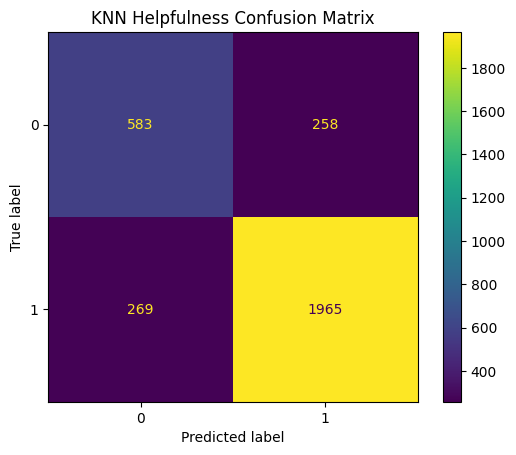

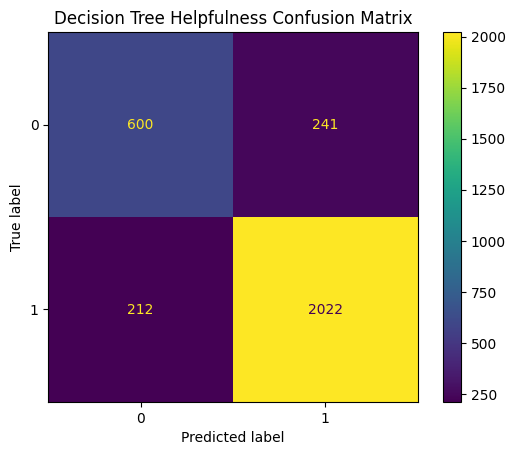

In [33]:
# Plot confusion matrix for both models
ConfusionMatrixDisplay.from_predictions(test_target_h, knn_h_pred, labels=[0, 1])
plt.title("KNN Helpfulness Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(test_target_h, tree_h_pred, labels=[0, 1])
plt.title("Decision Tree Helpfulness Confusion Matrix")
plt.show()

The confusion matrices show that the Decision Tree makes fewer errors than KNN. It correctly predicts 600 unhelpful reviews and 2022 helpful reviews, compared with 583 unhelpful and 1965 helpful for KNN.

The Decision Tree also produces fewer false positives and false negatives, which explains its stronger performance.

In [34]:
# Perform 10-fold cross-validation for the KNN pipeline
knn_h_scores = cross_val_score(
    knn_helpful_pipeline,
    X_helpful,
    y_helpful,
    cv=10,
    scoring="accuracy"
)

print("KNN Helpfulness cross-validation scores:")
print(knn_h_scores)
print("Mean KNN Helpfulness CV accuracy:", round(knn_h_scores.mean(), 5))

KNN Helpfulness cross-validation scores:
[0.82964889 0.80364109 0.81859558 0.83615085 0.80104031 0.83409239
 0.81912817 0.83734548 0.81132075 0.83018868]
Mean KNN Helpfulness CV accuracy: 0.82212


In [35]:
# Perform 10-fold cross-validation for the Decision Tree pipeline
tree_h_scores = cross_val_score(
    tree_helpful_pipeline,
    X_helpful,
    y_helpful,
    cv=10,
    scoring="accuracy"
)

print("Decision Tree Helpfulness cross-validation scores:")
print(tree_h_scores)
print("Mean Decision Tree Helpfulness CV accuracy:", round(tree_h_scores.mean(), 5))

Decision Tree Helpfulness cross-validation scores:
[0.8420026  0.84330299 0.85955787 0.84785436 0.83680104 0.84775537
 0.84580351 0.83669486 0.84124919 0.84385166]
Mean Decision Tree Helpfulness CV accuracy: 0.84449


Overall, the Decision Tree performed better than KNN for helpfulness classification across all main evaluation measures. It achieved higher accuracy, stronger F1-scores, and better cross-validation performance.

Both models were more successful at identifying helpful reviews than unhelpful reviews, mainly because helpful reviews were the majority class in the dataset. Predicting the minority unhelpful class is more challenging.

The helpfulness classification task achieved higher accuracy than the sentiment classification task. The best sentiment model, the Decision Tree, achieved around 0.80 accuracy, while the best helpfulness model achieved around 0.85 accuracy.

One reason for this may be that helpfulness is strongly related to review structure, such as review length and rating, while sentiment classification requires the model to distinguish more subtle language differences, especially for the neutral class.

Both tasks showed class imbalance. In sentiment classification, the neutral class was the most difficult to predict. In helpfulness classification, the unhelpful class was weaker than the helpful class. This shows why accuracy alone was not sufficient and why precision, recall, F1-score and confusion matrices were useful.